In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Notebook started successfully")

Notebook started successfully


In [140]:
import zipfile
import os

zip_path = "northstar_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("northstar_dataset")

print("Dataset extracted successfully")

print(os.listdir("northstar_dataset"))

Dataset extracted successfully
['northstar_dataset']


In [141]:
import os

for root, dirs, files in os.walk("northstar_dataset"):
    print("Folder:", root)
    print("Files:", files)
    print("-" * 50)

Folder: northstar_dataset
Files: []
--------------------------------------------------
Folder: northstar_dataset/northstar_dataset
Files: ['customers.csv', 'data_dictionary.csv', 'complaints.csv', 'app_events.csv', 'deliveries.csv', 'hubs.csv', 'incidents.csv', 'drivers.csv', 'vehicles.csv', 'orders.csv', 'README.txt']
--------------------------------------------------


In [142]:
data_path = "northstar_dataset/northstar_dataset/"

customers = pd.read_csv(data_path + "customers.csv")
orders = pd.read_csv(data_path + "orders.csv")
deliveries = pd.read_csv(data_path + "deliveries.csv")
drivers = pd.read_csv(data_path + "drivers.csv")
vehicles = pd.read_csv(data_path + "vehicles.csv")
hubs = pd.read_csv(data_path + "hubs.csv")
incidents = pd.read_csv(data_path + "incidents.csv")
complaints = pd.read_csv(data_path + "complaints.csv")
app_events = pd.read_csv(data_path + "app_events.csv")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("deliveries:", deliveries.shape)
print("drivers:", drivers.shape)
print("vehicles:", vehicles.shape)
print("hubs:", hubs.shape)
print("incidents:", incidents.shape)
print("complaints:", complaints.shape)
print("app_events:", app_events.shape)

customers: (650, 9)
orders: (1250, 11)
deliveries: (950, 13)
drivers: (170, 8)
vehicles: (120, 8)
hubs: (8, 5)
incidents: (280, 7)
complaints: (320, 10)
app_events: (640, 10)


In [143]:
deliveries["failed_delivery_flag"] = np.where(
    deliveries["delivery_status"].str.lower() == "failed", 1, 0
)

deliveries["delayed_delivery_flag"] = np.where(
    deliveries["delivery_status"].str.lower() == "delayed", 1, 0
)

deliveries["route_override_flag"] = np.where(
    deliveries["manual_route_override_count"] > 0, 1, 0
)

app_events["app_failure_flag"] = np.where(
    app_events["success_flag"] == 0, 1, 0
)

analysis_df = (
    deliveries
    .merge(orders, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(drivers, on="driver_id", how="left")
    .merge(vehicles, on="vehicle_id", how="left")
    .merge(hubs, on="hub_id", how="left")
)

print("Integrated analysis dataset:", analysis_df.shape)
analysis_df.head()

Integrated analysis dataset: (950, 52)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,CENTRAL,2024-06-09 16:18:00,78.4,29849,Active,v2.2,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,AIRPORT,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0,North Exchange,North,Dispatch,82


In [144]:
complaint_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    total_compensation=("compensation_amount", "sum"),
    avg_resolution_days=("resolution_days", "mean")
).reset_index()

incident_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count")
).reset_index()

app_summary = app_events.groupby("order_id").agg(
    app_event_count=("event_id", "count"),
    app_failure_count=("app_failure_flag", "sum"),
    avg_api_latency_ms=("api_latency_ms", "mean")
).reset_index()

analysis_df = (
    analysis_df
    .merge(complaint_summary, on="order_id", how="left")
    .merge(incident_summary, on="delivery_id", how="left")
    .merge(app_summary, on="order_id", how="left")
)

for col in ["complaint_count", "total_compensation", "incident_count", "app_event_count", "app_failure_count"]:
    analysis_df[col] = analysis_df[col].fillna(0)

analysis_df["high_risk_flag"] = np.where(
    (analysis_df["failed_delivery_flag"] == 1) |
    (analysis_df["delayed_delivery_flag"] == 1) |
    (analysis_df["complaint_count"] > 0) |
    (analysis_df["incident_count"] > 0) |
    (analysis_df["customer_rating_post_delivery"] < 3) |
    (analysis_df["total_compensation"] > 0),
    1, 0
)

print("Final analysis dataset:", analysis_df.shape)
analysis_df[["order_id", "delivery_status", "complaint_count", "incident_count", "app_event_count", "high_risk_flag"]].head()

Final analysis dataset: (950, 60)


,order_id,delivery_status,complaint_count,incident_count,app_event_count,high_risk_flag
0,O00938,Failed,0.0,1.0,0.0,1
1,O00004,OnTime,0.0,0.0,0.0,0
2,O00639,OnTime,0.0,0.0,0.0,0
3,O00313,Delayed,0.0,0.0,1.0,1
4,O00844,OnTime,0.0,0.0,1.0,0


In [145]:
total_deliveries = len(deliveries)
status_counts = deliveries["delivery_status"].value_counts()

failed = status_counts.get("Failed", 0)
delayed = status_counts.get("Delayed", 0)
on_time = status_counts.get("OnTime", 0)

print("Total deliveries:", total_deliveries)
print("OnTime deliveries:", on_time)
print("Delayed deliveries:", delayed)
print("Failed deliveries:", failed)
print("Failed %:", round(failed / total_deliveries * 100, 2))
print("Delayed %:", round(delayed / total_deliveries * 100, 2))

Total deliveries: 950
OnTime deliveries: 616
Delayed deliveries: 202
Failed deliveries: 132
Failed %: 13.89
Delayed %: 21.26


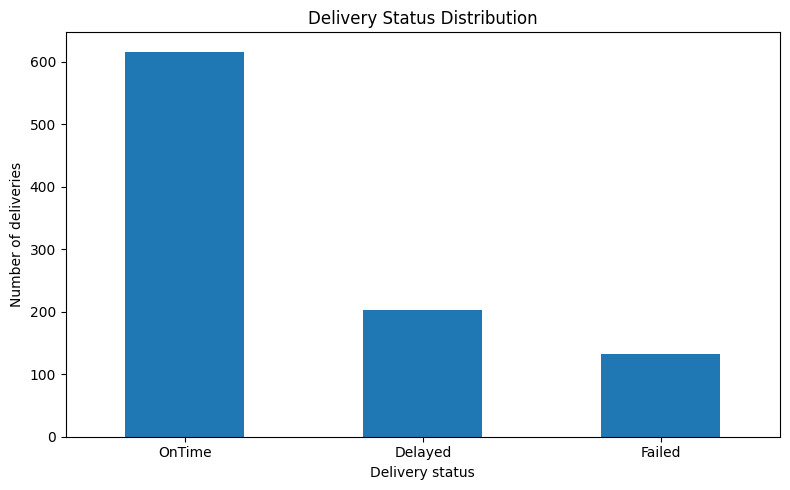

In [146]:
status_order = ["OnTime", "Delayed", "Failed"]
status_counts = deliveries["delivery_status"].value_counts().reindex(status_order)

plt.figure(figsize=(8, 5))
status_counts.plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery status")
plt.ylabel("Number of deliveries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [147]:
zone_summary = analysis_df.groupby("zone").agg(
    deliveries=("delivery_id", "count"),
    failed=("failed_delivery_flag", "sum"),
    delayed=("delayed_delivery_flag", "sum"),
    avg_rating=("customer_rating_post_delivery", "mean")
).reset_index()

zone_summary["failure_percent"] = round(zone_summary["failed"] / zone_summary["deliveries"] * 100, 2)
zone_summary["delayed_percent"] = round(zone_summary["delayed"] / zone_summary["deliveries"] * 100, 2)
zone_summary["avg_rating"] = round(zone_summary["avg_rating"], 2)

zone_summary = zone_summary.sort_values("failure_percent", ascending=False)

zone_summary

,zone,deliveries,failed,delayed,avg_rating,failure_percent,delayed_percent
1,Central,243,49,47,3.78,20.16,19.34
0,Airport,104,15,27,3.88,14.42,25.96
6,West,127,16,28,3.92,12.60,22.05
3,North,136,17,26,3.84,12.50,19.12
4,Riverside,115,14,25,3.88,12.17,21.74
5,South,106,10,26,3.95,9.43,24.53
2,East,119,11,23,3.90,9.24,19.33


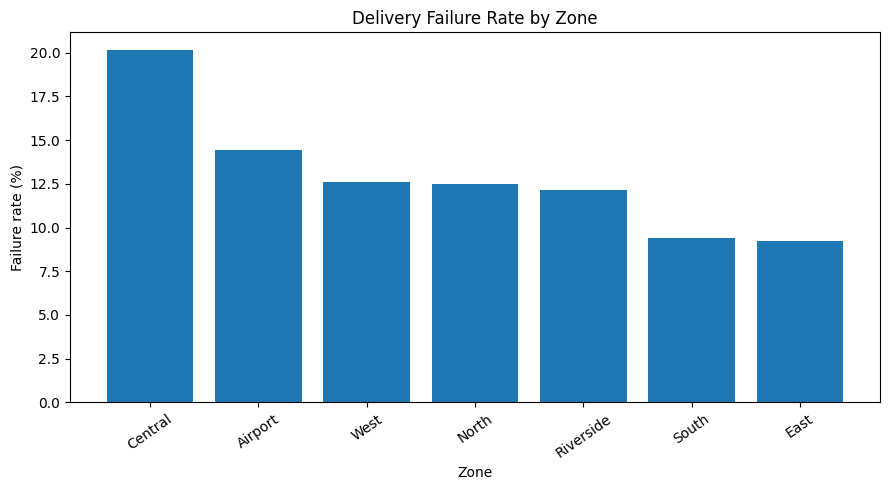

In [148]:
plt.figure(figsize=(9, 5))
plt.bar(zone_summary["zone"], zone_summary["failure_percent"])
plt.title("Delivery Failure Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [149]:
complaints_orders = complaints.merge(orders, on="order_id", how="left")

complaints_by_service = complaints_orders.groupby("service_type").agg(
    complaints=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

complaints_by_service["avg_resolution_days"] = round(complaints_by_service["avg_resolution_days"], 2)
complaints_by_service["total_compensation"] = round(complaints_by_service["total_compensation"], 2)

complaints_by_service = complaints_by_service.sort_values("complaints", ascending=False)

complaints_by_service

,service_type,complaints,avg_resolution_days,total_compensation
3,Passenger,84,7.74,1657.53
4,Retail,83,7.89,1486.14
2,Parcel,77,8.34,1463.65
0,Business,39,7.95,810.86
1,Medical,37,7.57,740.01


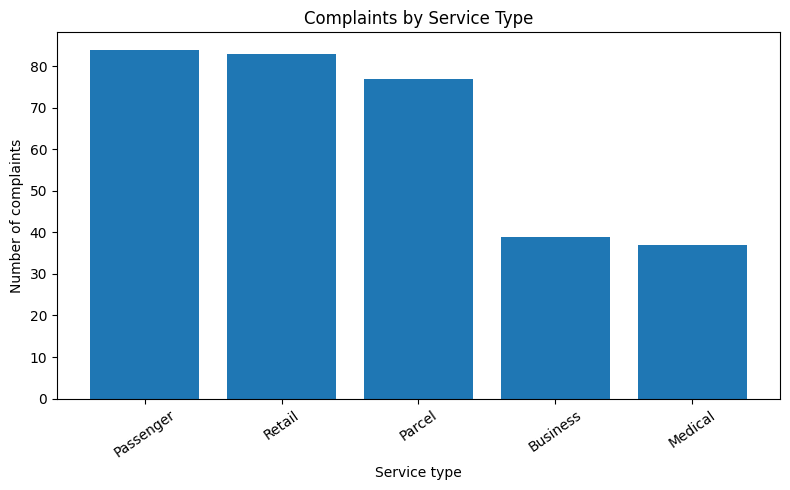

In [150]:
plt.figure(figsize=(8, 5))
plt.bar(complaints_by_service["service_type"], complaints_by_service["complaints"])
plt.title("Complaints by Service Type")
plt.xlabel("Service type")
plt.ylabel("Number of complaints")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [151]:
route_override_summary = analysis_df.groupby("route_override_flag").agg(
    deliveries=("delivery_id", "count"),
    failed=("failed_delivery_flag", "sum"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_cost=("fuel_or_charge_cost", "mean")
).reset_index()

route_override_summary["failure_rate"] = round(
    route_override_summary["failed"] / route_override_summary["deliveries"] * 100, 2
)

route_override_summary["route_override_group"] = route_override_summary["route_override_flag"].map({
    0: "No route override",
    1: "Route override used"
})

route_override_summary

,route_override_flag,deliveries,failed,avg_customer_rating,avg_cost,failure_rate,route_override_group
0,0,399,46,3.900816,12.429549,11.53,No route override
1,1,551,86,3.838640,13.139456,15.61,Route override used


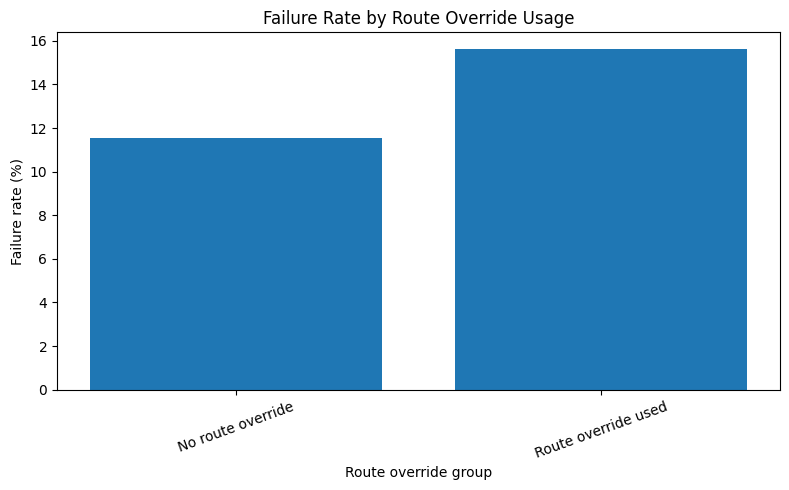

In [152]:
plt.figure(figsize=(8, 5))
plt.bar(route_override_summary["route_override_group"], route_override_summary["failure_rate"])
plt.title("Failure Rate by Route Override Usage")
plt.xlabel("Route override group")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [153]:
vehicle_summary = analysis_df.groupby("maintenance_status").agg(
    deliveries=("delivery_id", "count"),
    failed=("failed_delivery_flag", "sum"),
    avg_battery_health=("battery_health_pct", "mean"),
    avg_customer_rating=("customer_rating_post_delivery", "mean")
).reset_index()

vehicle_summary["failure_rate"] = round(
    vehicle_summary["failed"] / vehicle_summary["deliveries"] * 100, 2
)

vehicle_summary["avg_battery_health"] = round(vehicle_summary["avg_battery_health"], 2)
vehicle_summary["avg_customer_rating"] = round(vehicle_summary["avg_customer_rating"], 2)

vehicle_summary = vehicle_summary.sort_values("failure_rate", ascending=False)

vehicle_summary

,maintenance_status,deliveries,failed,avg_battery_health,avg_customer_rating,failure_rate
1,InRepair,254,77,76.73,3.63,30.31
0,Active,542,45,76.56,3.95,8.30
2,Scheduled,154,10,78.74,3.93,6.49


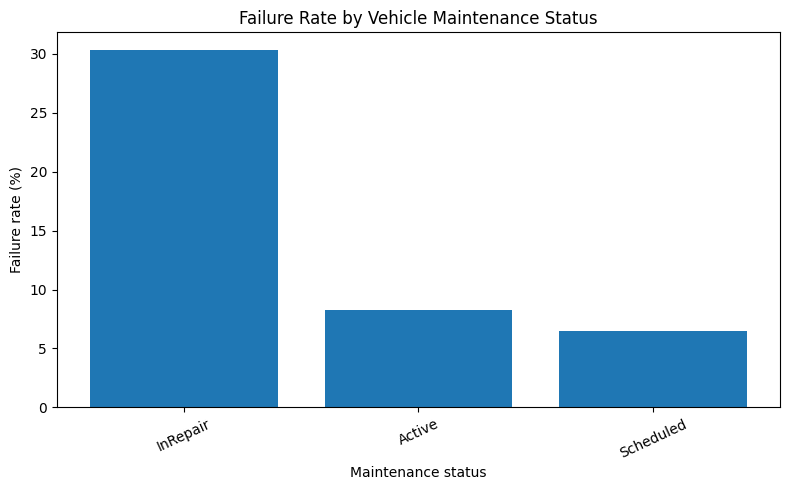

In [154]:
plt.figure(figsize=(8, 5))
plt.bar(vehicle_summary["maintenance_status"], vehicle_summary["failure_rate"])
plt.title("Failure Rate by Vehicle Maintenance Status")
plt.xlabel("Maintenance status")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [155]:
analysis_df.to_csv("northstar_integrated_analysis.csv", index=False)
zone_summary.to_csv("zone_summary.csv", index=False)
complaints_by_service.to_csv("complaints_by_service.csv", index=False)
route_override_summary.to_csv("route_override_summary.csv", index=False)
vehicle_summary.to_csv("vehicle_summary.csv", index=False)

print("Python notebook outputs saved successfully.")

Python notebook outputs saved successfully.
